# Illesztett szűrő linear chirp jelhez

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, convolve, gausspulse

# working with [us,MHz]
res = 1e4
T = 10
t = np.arange(0, T, 1/res)
B = 12
f_0 = 40000
phi = np.pi/1.7
fst_solve=1

In [13]:
s_linchirp = chirp(t, f0=f_0, t1=T, f1=f_0 + B, method='linear')

t_sym = np.concatenate((-t[len(t)//2-1::-1], t[:len(t)//2]))
s_gauss = gausspulse(t_sym,f_0,B)

signal = s_gauss
if fst_solve:
    matched_filter = np.conj(signal[::-1])
else:
    matched_filter = np.conj(s_linchirp)

In [14]:
SNR_dB = -30
signal_power = np.mean(np.abs(signal)**2)
noise_power = signal_power / (10**(SNR_dB/10))
noise = np.sqrt(noise_power) * np.random.randn(len(signal))

In [15]:
rx = (signal + noise) * np.exp(1j*phi)
if fst_solve:
    y = convolve(rx, matched_filter, mode='same')
else:
    y = np.correlate(rx, matched_filter, mode='same')

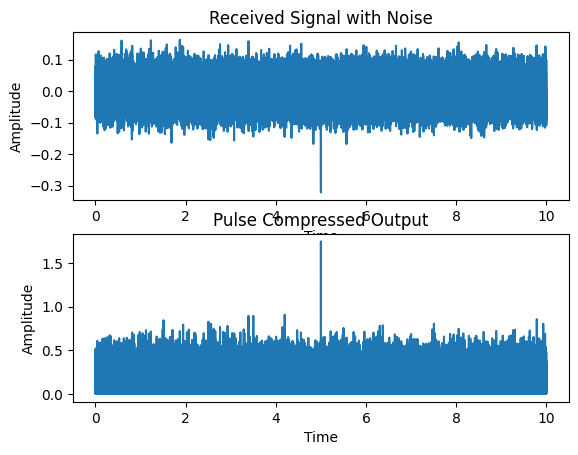

In [16]:
plt.subplot(2,1,1)
plt.plot(t, rx)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Received Signal with Noise')

plt.subplot(2,1,2)
plt.plot(t, np.abs(y))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Compressed Output')

plt.show()